In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pulp import *
from scipy.spatial.distance import cdist
from matplotlib.patches import Rectangle

In [8]:
#Parámetros del problema
m=20 #Número de usuarios
n=20 #Número máximo de médicos
dt=10 #Tiempo en minutos
K=144 #Número de intervalos de Tiempo
velocidad=30 #En unidades de km/hora
r=np.random.uniform(low=0, high=30, size=(m,2)) #Posiciones de los usuarios
distancias = cdist(r, r)
delta=distancias/velocidad*60 #Matriz de distancias en minutos
delta=np.ceil(delta/dt) #Matriz de distancias en intervalos de tiempo
delta={(i+1,j+1):delta[i,j] for i in range(0,m) for j in range(0,m)}


#Generación de parámetros de servicio de los pacientes
a={i:np.random.randint(low=1, high=K-10) for i in range(1,m+1)} #Tiempo de llegada de los usuarios
b={}
c={}
for i in range(1,m+1):
    ventana=np.random.randint(low=4, high=20) #Duración de la ventana de servicio
    ventana=min(144-a[i]-1, ventana)
    b[i]=a[i]+ventana+1
    duracion=np.random.randint(low=1, high=b[i]-a[i])
    c[i]=duracion

#Parámetros auxiliares para construir las ecuaciones
alfa={}
tau={i:[] for i in range(1,m+1)}
for i in range(1,m+1):
    for k in range(1, K+1):
        if(k>=a[i] and k<=b[i]-c[i]+1):
            alfa[i,k]=1
            tau[i].append(k)
        else:
            alfa[i,k]=0



In [9]:
prob=LpProblem('Optimizacion_turnos', LpMinimize) #Dado que importamos toda la librería de Pulp
#Construccion de variables
#Uso de médicos:
y={j:LpVariable('Doctor_'+str(j), cat=LpBinary) for j in range(1,n+1)}
x={}
for i in range(1,m+1):
    for j in range(1, n+1):
        for k in range(1,K+1):
            if(alfa[i,k]==1): 
                x[i,j,k]=LpVariable(f'Us{i}_Dr{j}_Time{k}', cat=LpBinary)

#Función objetivo
prob+=lpSum([y[j] for j in range(1,n+1)]), 'Función objetivo'

#Restricción de que alguien tiene que atender al usuario, pero solo un doctor
for i in range(1,m+1):
    suma=0
    for j in range(1,n+1):
        for k in tau[i]:
            suma+=x[i,j,k]
    prob+=suma==1, 'Atención del usuario '+str(i)

#Restricciones de tiempo entre atención y desplazamiento
M=1000
for i in range(1,m+1):
    for j in range(1,n+1):
        for k in tau[i]:
            suma=0
            for eta in [i2 for i2 in range(1,m+1) if i2!=i]:
                for s in range(int(k-c[eta]-delta[eta,i]+1),k+1):
                    if((eta,j,s) in x.keys()):
                        suma+=x[eta,j,s]
            prob+=x[i,j,k]<=1-1/M*suma

#Restricción 3, el médico puede atender si está activo
for j in range(1,n+1):
    suma=0
    for i in range(1,m+1):
        for k in tau[i]:
            suma+=x[i,j,k]
    prob+=suma<=M*y[j], f'El profesor {j} atiende si está activo'



In [ ]:
prob.solve()

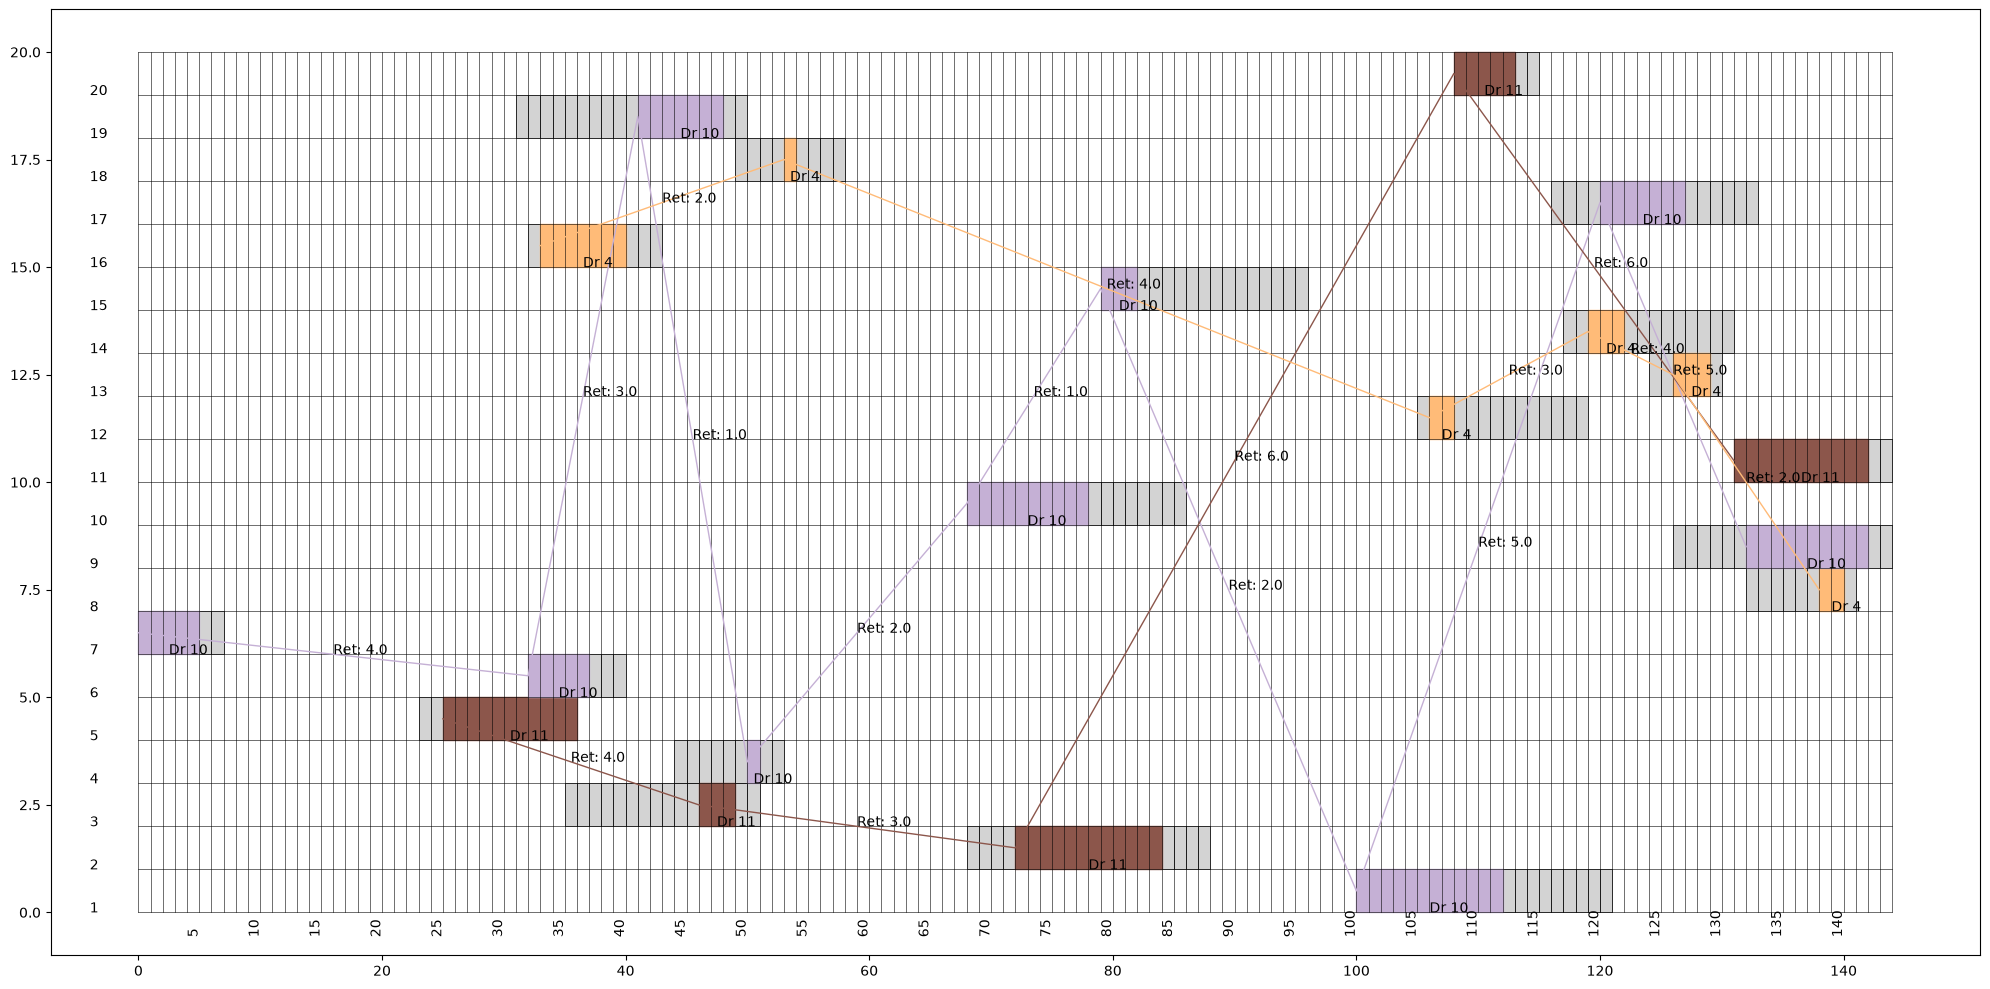

In [ ]:
#Visualización del resultado
cmap = plt.get_cmap('tab20')
colors = [cmap(i % cmap.N) for i in range(n)] #Para cada médico

plt.figure(figsize=(20,10))
ax=plt.gca()
lw=0.4
for i in range(0, m+1):
    plt.plot([0,K],[i,i], '-k', linewidth=lw)
    if(i<=m-1):
        plt.text(-4,i,str(i+1))
for k in range(0, K+1):
    plt.plot([k,k],[0,m], '-k', linewidth=lw)
    if(k<=K-1 and (k+1)%5==0):
        plt.text(k,-0.5,str(k+1), fontsize=10, rotation=90)

for i in range(1,m+1):
    for k in range(a[i], b[i]+1):
        rect = Rectangle(
            (k-1,i-1),          # esquina inferior izquierda (x,y)
            1,               # ancho
            1,             # alto
            facecolor='lightgray', # color de relleno
            edgecolor='black', # borde
            linewidth=lw
        )

        ax.add_patch(rect)
atenciones={}        
for key,v in x.items():
    if(v.varValue>0):
        i,j,k=key
        if(j not in atenciones.keys()):
            atenciones[j]=[]
        atenciones[j].append((i,k))
        for ni in range(0,c[i]):
            rect = Rectangle(
                (k-1+ni, i-1),          # esquina inferior izquierda (x,y)
                1,               # ancho
                1,             # alto
                facecolor=colors[j-1], # color de relleno
                edgecolor=colors[j-1], # borde
                linewidth=1
            )

            ax.add_patch(rect)
        centro=k-1+c[i]/2
        plt.text(centro, i-1, f'Dr {j}')
        
for k,v in atenciones.items(): 
    v=sorted(v, key=lambda t: t[1], reverse=False)
    xi=[vi[1]-1 for vi in v]       
    yi=[vi[0]-0.5 for vi in v]
    plt.plot(xi,yi,'-', linewidth=1, color=colors[k-1])
    for i in range(len(xi)-1):
        u1,u2=yi[i],yi[i+1]
        ret=delta[int(u1+0.5),int(u2+0.5)]
        plt.text((xi[i]+xi[i+1])/2,(yi[i]+yi[i+1])/2, f'Ret: {ret}')
plt.tight_layout()

In [ ]:
n

20